# **Kết nối Drive & Import Libraries**

In [8]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# import library
import os
import shutil
import cv2
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow import keras
from keras.callbacks import EarlyStopping,ModelCheckpoint
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, AveragePooling2D, Concatenate, Flatten, Dense
from tensorflow.keras import Model
from keras.optimizers import Adam
import matplotlib.pyplot as plt

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **Define Paths**

In [9]:
# Đường dẫn tới dataset ĐÃ XỬ LÝ (Student-engagement-dataset-clean)
data_path = "/content/drive/MyDrive/Project_CV/Student-engagement-dataset-clean"

# Thư mục tạm trên Colab để train cho nhanh (IO speed cao hơn Drive)
target_path = '/content/Student-engagement-Processed-Temp'
train_dir = os.path.join(target_path, 'train')
test_dir = os.path.join(target_path, 'test')
valid_dir = os.path.join(target_path, 'validation')

os.makedirs(target_path, exist_ok=True)
os.makedirs(train_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)
os.makedirs(valid_dir, exist_ok=True)

print(f"Đã tạo các thư mục: {target_path}")

Đã tạo các thư mục: /content/Student-engagement-Processed-Temp


# **Data Preprocessing - Copy dữ liệu (KHÔNG resize/normalize lại)**

In [10]:
for path_ in os.listdir(data_path):
    main_class_dir = os.path.join(data_path, path_)
    if not os.path.isdir(main_class_dir): continue

    for subclass_name in os.listdir(main_class_dir):
        subclass_dir = os.path.join(main_class_dir, subclass_name)
        if not os.path.isdir(subclass_dir): continue

        img_count = len(os.listdir(subclass_dir))
        test_img_count = int(0.2*img_count)
        train_img_count = img_count - test_img_count

        target_train_class_dir = os.path.join(train_dir, subclass_name)
        target_test_class_dir = os.path.join(test_dir, subclass_name)
        target_valid_class_dir = os.path.join(valid_dir, subclass_name)

        os.makedirs(target_train_class_dir,exist_ok=True)
        os.makedirs(target_test_class_dir,exist_ok=True)
        os.makedirs(target_valid_class_dir,exist_ok=True)

        for file_name in os.listdir(subclass_dir):
            src_path = os.path.join(subclass_dir, file_name)

            if len(os.listdir(target_test_class_dir)) != test_img_count:
                shutil.copy(src_path, os.path.join(target_test_class_dir, file_name))
            else:
                shutil.copy(src_path, os.path.join(target_train_class_dir, file_name))

# **Split Train into train and validation**

In [11]:
for class_folder in os.listdir(train_dir):
    train_class_dir = os.path.join(train_dir, class_folder)
    valid_class_dir = os.path.join(valid_dir, class_folder)

    train_ = os.path.join(target_path,'Train_Final')
    os.makedirs(train_,exist_ok=True)
    new_class_dir = os.path.join(train_,class_folder)
    os.makedirs(new_class_dir,exist_ok=True)

    img_count = len(os.listdir(train_class_dir))
    valid_img_count = int(0.2*img_count)
    train_img_count = img_count - valid_img_count

    for file_name in os.listdir(train_class_dir):
        src_path = os.path.join(train_class_dir, file_name)

        if len(os.listdir(valid_class_dir)) != valid_img_count:
            shutil.copy(src_path, os.path.join(valid_class_dir, file_name))
        else:
            shutil.copy(src_path, os.path.join(new_class_dir, file_name))

shutil.rmtree(train_dir)
train_dir = train_

# **Create Data Generators với Augmentation**

In [12]:
batch_size = 32
img_size = (128, 128)

# Thêm rescale ở đây
train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
        train_dir,
        target_size=img_size,
        batch_size=batch_size,
        class_mode = 'categorical',
        color_mode = 'grayscale',
        shuffle=True)

val_generator = val_datagen.flow_from_directory(
        valid_dir,
        target_size=img_size,
        batch_size=batch_size,
        class_mode = 'categorical',
        color_mode = 'grayscale',
        shuffle=True)

test_generator = test_datagen.flow_from_directory(
        test_dir,
        target_size=img_size,
        batch_size=batch_size,
        class_mode = 'categorical',
        color_mode = 'grayscale',
        shuffle=False) # False để tí extract feature cho đúng thứ tự

print(train_generator.class_indices)

Found 1711 images belonging to 6 classes.
Found 421 images belonging to 6 classes.
Found 421 images belonging to 6 classes.
{'Looking Away': 0, 'bored': 1, 'confused': 2, 'drowsy': 3, 'engaged': 4, 'frustrated': 5}


# **Build CNN Model - Feature Extractor**

In [13]:
model = keras.models.Sequential([
    Input(shape=(128, 128, 1)),

    # Block 1
    keras.layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    keras.layers.MaxPooling2D(2,2),

    # Block 2
    keras.layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    keras.layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    keras.layers.MaxPooling2D(2,2),

    # Block 3
    keras.layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    keras.layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    keras.layers.MaxPooling2D(2,2), # Sửa (3,3) -> (2,2)

    # Block 4
    keras.layers.Conv2D(256, (3,3), activation='relu', padding='same'),
    keras.layers.Conv2D(256, (3,3), activation='relu', padding='same'),

    keras.layers.Flatten(),

    # Lớp đặc trưng (QUAN TRỌNG)
    keras.layers.Dense(512, activation='relu', name='feature_layer'),

    # Lớp Softmax
    keras.layers.Dense(6, activation='softmax')
])

model.summary()

model.compile(optimizer=Adam(learning_rate=0.001),
              loss="categorical_crossentropy",
              metrics=['accuracy'])

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 65536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ feature_layer (Dense)           │ (None, 512)            │    33,554,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         3,078 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,720,454 (132.45 MB)

 Trainable params: 34,720,454 (132.45 MB)

 Non-trainable params: 0 (0.00 B)

# **Training với Callbacks**

In [14]:
drive_model_path = "/content/drive/MyDrive/Project_CV/Student Engagement Model.h5"

checkpoint = ModelCheckpoint(
    drive_model_path,
    monitor='val_accuracy',
    verbose=1,
    save_best_only=True,
    save_weights_only=False,
    mode='auto',
    save_freq='epoch'
)

early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=15,
    verbose=1,
    restore_best_weights=True
)

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=200,
    callbacks=[checkpoint, early_stopping]
)

Epoch 1/200
53/54 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - accuracy: 0.4755 - loss: 1.3007
Epoch 1: val_accuracy improved from -inf to 0.85036, saving model to /content/drive/MyDrive/Project_CV/Student Engagement Model.h5


54/54 ━━━━━━━━━━━━━━━━━━━━ 19s 286ms/step - accuracy: 0.4826 - loss: 1.2843 - val_accuracy: 0.8504 - val_loss: 0.3473
Epoch 2/200
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.8607 - loss: 0.3125
Epoch 2: val_accuracy improved from 0.85036 to 0.89786, saving model to /content/drive/MyDrive/Project_CV/Student Engagement Model.h5


54/54 ━━━━━━━━━━━━━━━━━━━━ 5s 99ms/step - accuracy: 0.8610 - loss: 0.3120 - val_accuracy: 0.8979 - val_loss: 0.2561
Epoch 3/200
53/54 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.9113 - loss: 0.2099
Epoch 3: val_accuracy improved from 0.89786 to 0.93349, saving model to /content/drive/MyDrive/Project_CV/Student Engagement Model.h5


54/54 ━━━━━━━━━━━━━━━━━━━━ 6s 117ms/step - accuracy: 0.9116 - loss: 0.2091 - val_accuracy: 0.9335 - val_loss: 0.1623
Epoch 4/200
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.9425 - loss: 0.1498
Epoch 4: val_accuracy did not improve from 0.93349
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - accuracy: 0.9425 - loss: 0.1496 - val_accuracy: 0.9145 - val_loss: 0.1760
Epoch 5/200
53/54 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.9461 - loss: 0.1235
Epoch 5: val_accuracy improved from 0.93349 to 0.95962, saving model to /content/drive/MyDrive/Project_CV/Student Engagement Model.h5


54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 79ms/step - accuracy: 0.9459 - loss: 0.1237 - val_accuracy: 0.9596 - val_loss: 0.1159
Epoch 6/200
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.9530 - loss: 0.1034
Epoch 6: val_accuracy did not improve from 0.95962
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.9529 - loss: 0.1034 - val_accuracy: 0.9572 - val_loss: 0.0882
Epoch 7/200
53/54 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.9638 - loss: 0.0837
Epoch 7: val_accuracy did not improve from 0.95962
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.9636 - loss: 0.0842 - val_accuracy: 0.9359 - val_loss: 0.1072
Epoch 8/200
53/54 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.9577 - loss: 0.0904
Epoch 8: val_accuracy did not improve from 0.95962
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.9578 - loss: 0.0900 - val_accuracy: 0.9525 - val_loss: 0.1376
Epoch 9/200
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.9617 - loss: 0.0839
Epoch 9: val_accuracy did not improve f

54/54 ━━━━━━━━━━━━━━━━━━━━ 10s 140ms/step - accuracy: 0.9751 - loss: 0.0584 - val_accuracy: 0.9739 - val_loss: 0.0865
Epoch 13/200
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.9760 - loss: 0.0646
Epoch 13: val_accuracy did not improve from 0.97387
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.9760 - loss: 0.0645 - val_accuracy: 0.9549 - val_loss: 0.0902
Epoch 14/200
53/54 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.9667 - loss: 0.0679
Epoch 14: val_accuracy improved from 0.97387 to 0.97625, saving model to /content/drive/MyDrive/Project_CV/Student Engagement Model.h5


54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 78ms/step - accuracy: 0.9669 - loss: 0.0677 - val_accuracy: 0.9762 - val_loss: 0.0766
Epoch 15/200
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.9726 - loss: 0.0624
Epoch 15: val_accuracy did not improve from 0.97625
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - accuracy: 0.9726 - loss: 0.0622 - val_accuracy: 0.9667 - val_loss: 0.0774
Epoch 16/200
53/54 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.9786 - loss: 0.0514
Epoch 16: val_accuracy improved from 0.97625 to 0.97862, saving model to /content/drive/MyDrive/Project_CV/Student Engagement Model.h5


54/54 ━━━━━━━━━━━━━━━━━━━━ 7s 81ms/step - accuracy: 0.9785 - loss: 0.0515 - val_accuracy: 0.9786 - val_loss: 0.0611
Epoch 17/200
53/54 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.9779 - loss: 0.0421
Epoch 17: val_accuracy did not improve from 0.97862
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.9777 - loss: 0.0424 - val_accuracy: 0.9762 - val_loss: 0.0584
Epoch 18/200
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.9846 - loss: 0.0387
Epoch 18: val_accuracy improved from 0.97862 to 0.98100, saving model to /content/drive/MyDrive/Project_CV/Student Engagement Model.h5


54/54 ━━━━━━━━━━━━━━━━━━━━ 7s 128ms/step - accuracy: 0.9845 - loss: 0.0389 - val_accuracy: 0.9810 - val_loss: 0.0578
Epoch 19/200
53/54 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.9840 - loss: 0.0477
Epoch 19: val_accuracy did not improve from 0.98100
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.9838 - loss: 0.0479 - val_accuracy: 0.9786 - val_loss: 0.0583
Epoch 20/200
53/54 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.9781 - loss: 0.0452
Epoch 20: val_accuracy did not improve from 0.98100
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.9780 - loss: 0.0452 - val_accuracy: 0.9810 - val_loss: 0.0467
Epoch 21/200
53/54 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.9739 - loss: 0.0434
Epoch 21: val_accuracy did not improve from 0.98100
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.9739 - loss: 0.0435 - val_accuracy: 0.9691 - val_loss: 0.0656
Epoch 22/200
53/54 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.9721 - loss: 0.0497
Epoch 22: val_accuracy did not 

In [15]:
# Đánh giá
test_loss, test_accuracy = model.evaluate(test_generator)

# Print the test loss and accuracy
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9724 - loss: 0.0717
Test Loss: 0.0841
Test Accuracy: 0.9644


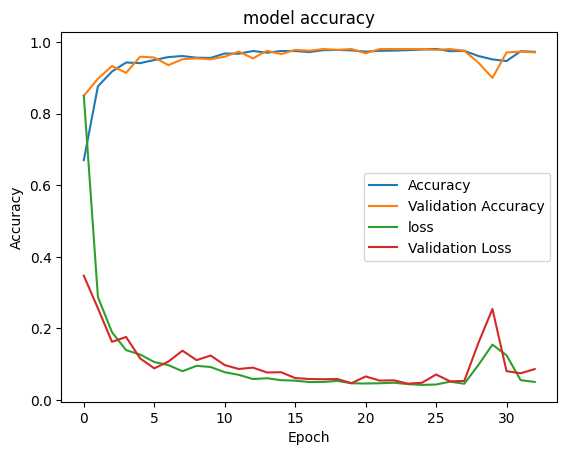

In [16]:
# Vẽ đồ thị
plt.plot(history.history["accuracy"])
plt.plot(history.history['val_accuracy'])
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("model accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.legend(["Accuracy","Validation Accuracy","loss","Validation Loss"])
plt.show()

In [18]:
print(model.built)

True


In [19]:
from tensorflow.keras import Model

feature_model = Model(
    inputs=model.layers[0].input,
    outputs=model.get_layer("feature_layer").output
)

feature_model.summary()

feature_only_path = "/content/drive/MyDrive/Project_CV/CNN_feature.h5"
feature_model.save(feature_only_path)

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 65536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ feature_layer (Dense)           │ (None, 512)            │    33,554,944 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,717,376 (132.44 MB)

 Trainable params: 34,717,376 (132.44 MB)

 Non-trainable params: 0 (0.00 B)